In [4]:
import pandas as pd
import os
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from PIL import Image, ImageDraw

data_path = '../data/'

In [2]:
from PIL import Image, ImageDraw
import numpy as np

def overlay_km_on_image(
    base_img: Image.Image,
    kmf,
    x_start_coord: tuple,
    x_end_coord: tuple,
    y_start_coord: tuple,
    y_end_coord: tuple,
    *,
    t_min: float | None = None,
    t_max: float | None = None,
    y_min: float = 0.0,
    y_max: float = 1.0,
    line_width: int = 4,
    color: str | tuple = "red",
    legend_label: str | None = None,
    legend_pos: str = "top_right",  # "top_right", "top_left", "bottom_left", "bottom_right"
    # --- NEW optional kwargs for CI ---
    show_ci: bool = True,
    ci_alpha: int = 80,             # 0-255 transparency
    ci_color: str | tuple | None = None,
):
    """
    Overlay a Kaplan-Meier curve onto an existing image with optional legend
    and (optionally) a shaded confidence interval derived from kmf.confidence_interval_.
    """

    # --- build stepwise curve (same as before) ---
    sf = kmf.survival_function_.copy()
    if "KM_estimate" in sf.columns:
        s = sf["KM_estimate"].to_numpy()
    else:
        s = sf.iloc[:, 0].to_numpy()
    t = sf.index.to_numpy(dtype=float)

    if t_min is None:
        t0 = 0.0 if (len(t) == 0 or t[0] > 0) else t[0]
    else:
        t0 = float(t_min)
    if len(t) == 0 or t[0] > t0:
        t = np.insert(t, 0, t0)
        s = np.insert(s, 0, 1.0)
    if t_max is None:
        t_max = float(np.max(t) if len(t) else 1.0)
    else:
        t_max = float(t_max)
    mask = (t >= t0) & (t <= t_max)
    t, s = t[mask], s[mask]

    step_t, step_s = [t[0]], [s[0]]
    for i in range(1, len(t)):
        step_t.append(t[i]); step_s.append(step_s[-1])
        step_t.append(t[i]); step_s.append(s[i])
    if step_t and step_t[-1] < t_max:
        step_t.append(t_max)
        step_s.append(step_s[-1])
    step_t, step_s = np.asarray(step_t), np.asarray(step_s)

    # --- axis mapping ---
    x0, y0 = x_start_coord
    x1, _ = x_end_coord
    _, y_top = y_end_coord
    px_dx, px_dy = float(x1 - x0), float(y0 - y_top)
    data_tx, data_sy = float(t_max - t0), float(y_max - y_min)

    def x_to_px(t_val): return x0 + (np.asarray(t_val) - t0) / (data_tx or 1.0) * px_dx
    def s_to_py(s_val): return y0 - (np.asarray(s_val) - y_min) / (data_sy or 1.0) * px_dy

    px, py = x_to_px(step_t), s_to_py(step_s)

    # Prepare image (RGBA for alpha compositing)
    base_mode = base_img.mode
    if base_mode != "RGBA":
        img = base_img.convert("RGBA")
    else:
        img = base_img.copy()

    # --- confidence interval shading ---
    if show_ci:
        ci_df = getattr(kmf, "confidence_interval_", None)
        if ci_df is not None and len(ci_df) > 0:
            # Try to identify lower/upper columns robustly
            cols_lower = [c for c in ci_df.columns if "lower" in c.lower()]
            cols_upper = [c for c in ci_df.columns if "upper" in c.lower()]
            if len(cols_lower) == 0 or len(cols_upper) == 0:
                # Fallback: assume first two columns are [lower, upper] in name-sorted order
                sorted_cols = sorted(ci_df.columns.tolist())
                if len(sorted_cols) >= 2:
                    lower_col, upper_col = sorted_cols[0], sorted_cols[1]
                else:
                    lower_col = upper_col = None
            else:
                lower_col, upper_col = cols_lower[0], cols_upper[0]

            if lower_col is not None and upper_col is not None:
                ci_t = ci_df.index.to_numpy(dtype=float)

                # Restrict to [t0, t_max] and ensure we start at t0 with S=1.0 if needed
                # Build stepwise for lower/upper just like main curve
                def build_step(times, vals, default_at_t0=1.0):
                    tt, vv = times.copy(), vals.copy()
                    if len(tt) == 0 or tt[0] > t0:
                        tt = np.insert(tt, 0, t0)
                        vv = np.insert(vv, 0, default_at_t0)
                    # clip to window
                    m = (tt >= t0) & (tt <= t_max)
                    tt, vv = tt[m], vv[m]
                    # stepwise
                    st_t, st_v = [tt[0]], [vv[0]]
                    for i in range(1, len(tt)):
                        st_t.append(tt[i]); st_v.append(st_v[-1])
                        st_t.append(tt[i]); st_v.append(vv[i])
                    if st_t and st_t[-1] < t_max:
                        st_t.append(t_max); st_v.append(st_v[-1])
                    return np.asarray(st_t), np.asarray(st_v)

                lower_vals = ci_df[lower_col].to_numpy()
                upper_vals = ci_df[upper_col].to_numpy()
                stl_t, stl_v = build_step(ci_t, lower_vals, default_at_t0=1.0)
                stu_t, stu_v = build_step(ci_t, upper_vals, default_at_t0=1.0)

                # Map to pixels
                x_lower, y_lower = x_to_px(stl_t), s_to_py(stl_v)
                x_upper, y_upper = x_to_px(stu_t), s_to_py(stu_v)

                # Build polygon: go along upper, then back along lower reversed
                poly_x = np.concatenate([x_upper, x_lower[::-1]])
                poly_y = np.concatenate([y_upper, y_lower[::-1]])
                polygon = list(map(tuple, np.column_stack([poly_x, poly_y])))

                # Draw translucent fill on a separate overlay
                overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
                odraw = ImageDraw.Draw(overlay, "RGBA")
                fill_color = ci_color if ci_color is not None else color
                # Normalize named color to RGB if needed (ImageDraw handles both)
                if isinstance(fill_color, str):
                    # Let PIL parse the color name and then add alpha
                    # We approximate by drawing with (named_color, alpha) via RGBA tuple:
                    try:
                        # Convert via a 1x1 image trick to resolve the RGB
                        tmp = Image.new("RGBA", (1, 1), fill_color)
                        r, g, b, _ = tmp.getpixel((0, 0))
                        rgba = (r, g, b, int(ci_alpha))
                    except Exception:
                        rgba = (255, 0, 0, int(ci_alpha))
                else:
                    # Tuple provided; extend to RGBA with given alpha
                    if len(fill_color) == 3:
                        rgba = (fill_color[0], fill_color[1], fill_color[2], int(ci_alpha))
                    elif len(fill_color) == 4:
                        rgba = (fill_color[0], fill_color[1], fill_color[2], int(ci_alpha))
                    else:
                        rgba = (255, 0, 0, int(ci_alpha))

                odraw.polygon(polygon, fill=rgba)
                # Composite overlay onto the image
                img = Image.alpha_composite(img, overlay)

    # --- draw main KM line on top ---
    draw = ImageDraw.Draw(img)
    for i in range(1, len(px)):
        draw.line([(px[i-1], py[i-1]), (px[i], py[i])], fill=color, width=line_width)

    # --- legend ---
    if legend_label:
        # choose position
        W, H = img.size
        margin, box_h, box_w = 20, 40, 180
        if legend_pos == "top_left":
            xL, yL = margin, margin
        elif legend_pos == "bottom_left":
            xL, yL = margin, H - box_h - margin
        elif legend_pos == "bottom_right":
            xL, yL = W - box_w - margin, H - box_h - margin
        else:  # top_right
            xL, yL = W - box_w - margin, margin
        # draw background rectangle
        draw.rectangle([xL, yL, xL + box_w, yL + box_h], fill="white", outline="black")
        # draw line symbol
        line_y = yL + box_h // 2
        draw.line([(xL + 10, line_y), (xL + 60, line_y)], fill=color, width=4)

        # CI swatch (if shown)
        if show_ci:
            ci_fill_preview = ci_color if ci_color is not None else color
            # Resolve to RGBA as above
            if isinstance(ci_fill_preview, str):
                try:
                    tmp = Image.new("RGBA", (1, 1), ci_fill_preview)
                    r, g, b, _ = tmp.getpixel((0, 0))
                    rgba_ci = (r, g, b, int(ci_alpha))
                except Exception:
                    rgba_ci = (255, 0, 0, int(ci_alpha))
            else:
                if len(ci_fill_preview) == 3:
                    rgba_ci = (ci_fill_preview[0], ci_fill_preview[1], ci_fill_preview[2], int(ci_alpha))
                elif len(ci_fill_preview) == 4:
                    rgba_ci = (ci_fill_preview[0], ci_fill_preview[1], ci_fill_preview[2], int(ci_alpha))
                else:
                    rgba_ci = (255, 0, 0, int(ci_alpha))

            # Draw a small translucent rectangle as CI swatch
            ci_x0, ci_y0 = xL + 10, yL + 8
            ci_x1, ci_y1 = xL + 60, yL + 18
            ci_overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
            ImageDraw.Draw(ci_overlay, "RGBA").rectangle([ci_x0, ci_y0, ci_x1, ci_y1], fill=rgba_ci, outline=None)
            img = Image.alpha_composite(img, ci_overlay)

        # draw text
        try:
            font = ImageFont.load_default()
        except Exception:
            font = None
        draw = ImageDraw.Draw(img)  # refresh after alpha composite
        draw.text((xL + 70, yL + (box_h // 2 - 8)), legend_label, fill="black", font=font)

    # Convert back to original mode if needed
    if base_mode != "RGBA":
        img = img.convert(base_mode)

    return img

# NCT02370498

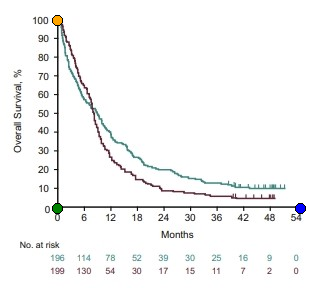

In [5]:
# Open image
nct_id = 'NCT02370498'
image_file = data_path + f"PD-L1/cleaned/{nct_id}_MT1.jpg"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (57, 208)
x_end_coord   = (300, 208)
y_start_coord = (57, 208)
y_end_coord   = (57, 20)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

# Draw circles on the image
for name, (coord, color) in points.items():
    x, y = coord
    r = 5
    draw.ellipse((x-r, y-r, x+r, y+r), fill=color, outline="black")

original_image

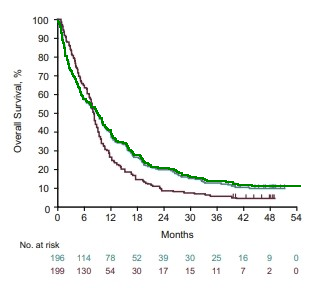

In [ ]:
output = pd.read_csv(data_path + f'PD-L1/{nct_id}_MT1_IPD.csv')
output = output[output['Group'] == 'Group1']

# Open image
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(output['time'], event_observed=output['status'])

overlaid = overlay_km_on_image(
    base_img=original_image,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=54,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=2,
    color="green",
    show_ci=False
)


overlaid

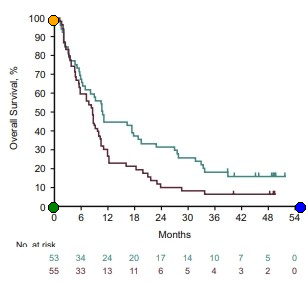

In [12]:
# Open image
nct_id = 'NCT02370498'
image_file = data_path + f"PD-L1/cleaned/{nct_id}_MT10.jpg"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (53, 207)
x_end_coord   = (300, 207)
y_start_coord = (53, 207)
y_end_coord   = (53, 20)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

# Draw circles on the image
for name, (coord, color) in points.items():
    x, y = coord
    r = 5
    draw.ellipse((x-r, y-r, x+r, y+r), fill=color, outline="black")

original_image

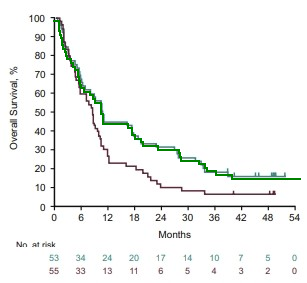

In [13]:
output = pd.read_csv(data_path + f'PD-L1/{nct_id}_MT10_IPD.csv')
output = output[output['Group'] == 'Group1']

# Open image
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(output['time'], event_observed=output['status'])

overlaid = overlay_km_on_image(
    base_img=original_image,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=54,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=2,
    color="green",
    show_ci=False
)

overlaid

# NCT02494583

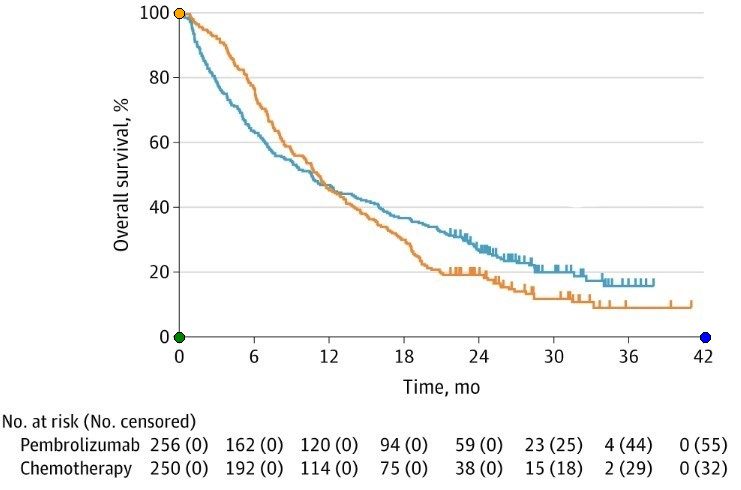

In [14]:
# Open image
nct_id = 'NCT02494583'
image_file = data_path + f"PD-L1/cleaned/{nct_id}_MT1.jpg"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (179, 337)
x_end_coord   = (705, 337)
y_start_coord = (179, 337)
y_end_coord   = (179, 13)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

# Draw circles on the image
for name, (coord, color) in points.items():
    x, y = coord
    r = 5
    draw.ellipse((x-r, y-r, x+r, y+r), fill=color, outline="black")

original_image

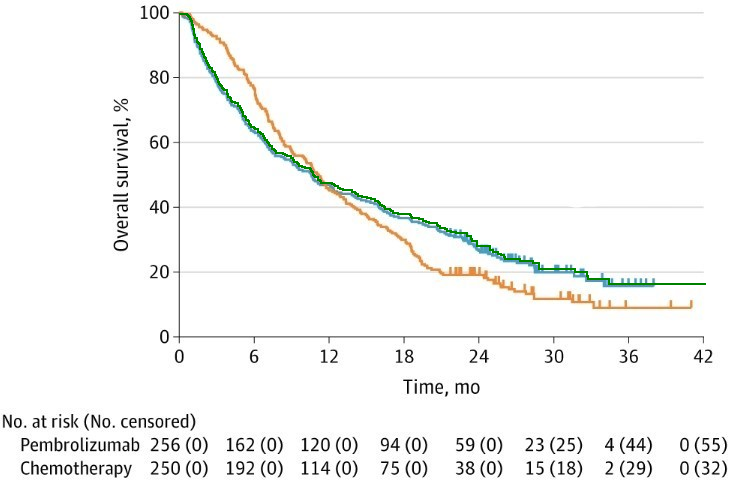

In [16]:
output = pd.read_csv(data_path + f'PD-L1/{nct_id}_MT1_IPD.csv')
output = output[output['Group'] == 'Pembrolizumab']

# Open image
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(output['time'], event_observed=output['status'])

overlaid = overlay_km_on_image(
    base_img=original_image,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=42,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=2,
    color="green",
    show_ci=False
)

overlaid

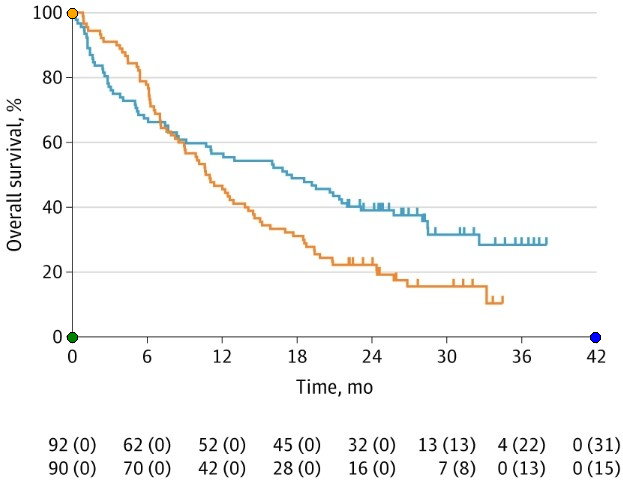

In [17]:
# Open image
nct_id = 'NCT02494583'
image_file = data_path + f"PD-L1/cleaned/{nct_id}_MT10.jpg"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (72, 337)
x_end_coord   = (595, 337)
y_start_coord = (72, 337)
y_end_coord   = (72, 13)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

# Draw circles on the image
for name, (coord, color) in points.items():
    x, y = coord
    r = 5
    draw.ellipse((x-r, y-r, x+r, y+r), fill=color, outline="black")

original_image

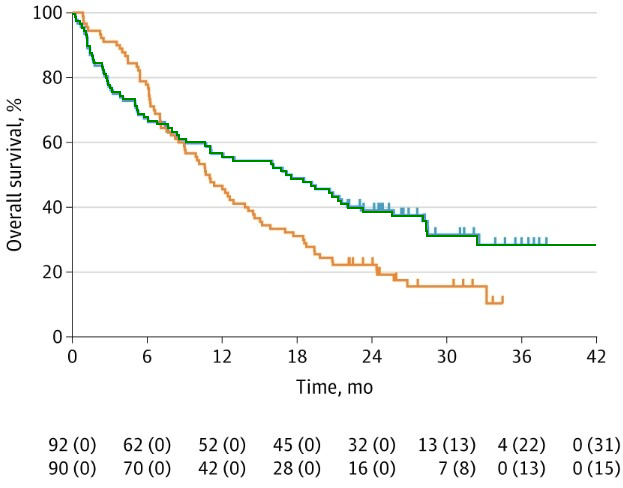

In [18]:
output = pd.read_csv(data_path + f'PD-L1/{nct_id}_MT10_IPD.csv')
output = output[output['Group'] == 'Group1']

# Open image
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(output['time'], event_observed=output['status'])

overlaid = overlay_km_on_image(
    base_img=original_image,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=42,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=2,
    color="green",
    show_ci=False
)


overlaid

# NCT02625610

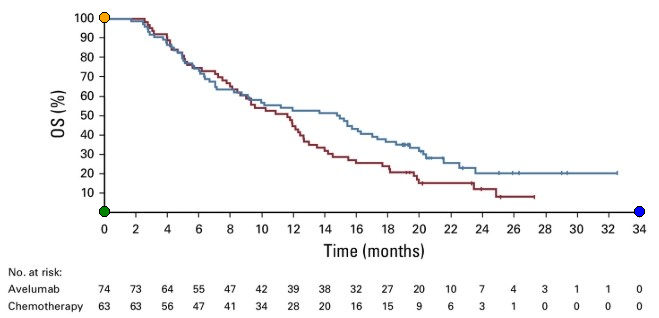

In [19]:
# Open image
nct_id = 'NCT02625610'
image_file = data_path + f"PD-L1/cleaned/{nct_id}_MT1.jpg"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (104, 211)
x_end_coord   = (639, 211)
y_start_coord = (104, 211)
y_end_coord   = (104, 17)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

# Draw circles on the image
for name, (coord, color) in points.items():
    x, y = coord
    r = 5
    draw.ellipse((x-r, y-r, x+r, y+r), fill=color, outline="black")

original_image

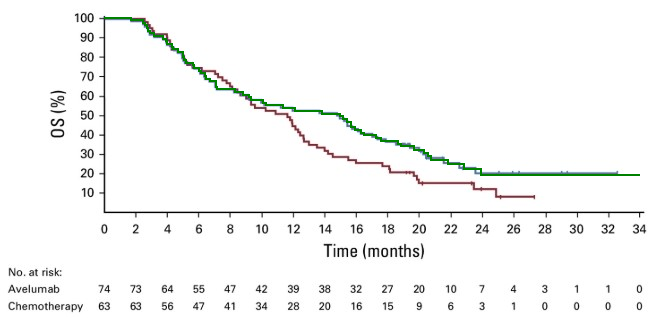

In [21]:
output = pd.read_csv(data_path + f'PD-L1/{nct_id}_MT1_IPD.csv')
output = output[output['Group'] == 'Avelumab']

# Open image
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(output['time'], event_observed=output['status'])

overlaid = overlay_km_on_image(
    base_img=original_image,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=34,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=2,
    color="green",
    show_ci=False
)




overlaid

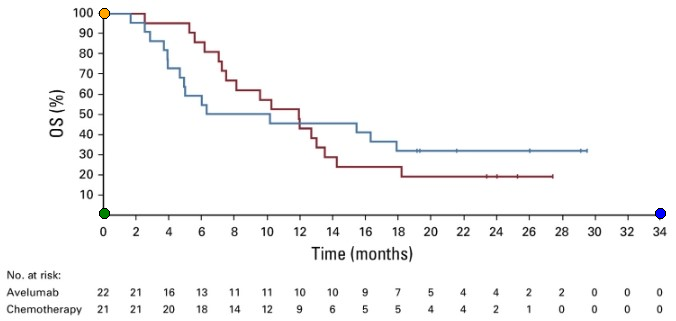

In [22]:
# Open image
nct_id = 'NCT02625610'
image_file = data_path + f"PD-L1/cleaned/{nct_id}_MT10.jpg"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (104, 213)
x_end_coord   = (660, 213)
y_start_coord = (104, 213)
y_end_coord   = (104, 13)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

# Draw circles on the image
for name, (coord, color) in points.items():
    x, y = coord
    r = 5
    draw.ellipse((x-r, y-r, x+r, y+r), fill=color, outline="black")

original_image

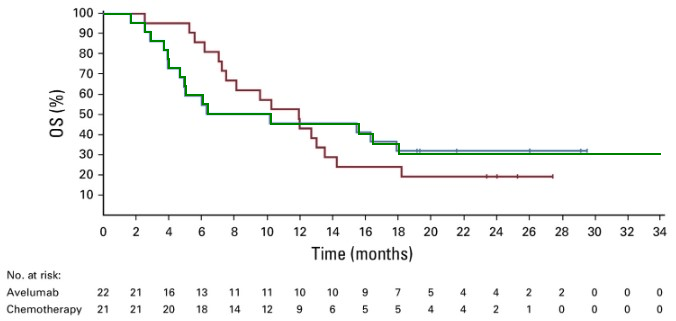

In [23]:
output = pd.read_csv(data_path + f'PD-L1/{nct_id}_MT10_IPD.csv')
output = output[output['Group'] == 'Avelumab']

# Open image
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(output['time'], event_observed=output['status'])

overlaid = overlay_km_on_image(
    base_img=original_image,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=34,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=2,
    color="green",
    show_ci=False
)

overlaid